# Baseline Model and Training
**Task:** Flood damage semantic segmentation using a U-Net baseline.

**Inputs:** `data/processed/metadata.csv` (columns: `pre_path`, `post_path`, `mask_path`)

**Outputs:**
- `outputs/prajwal/checkpoints/best_model.pth`
- `outputs/prajwal/loss_curve.png`
- `outputs/prajwal/training_log.csv`

## 1. Imports and Project Setup

In [5]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# ── Project root (works whether run from repo root or notebooks/) ──
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

METADATA_PATH  = PROJECT_ROOT / "data" / "processed" / "metadata.csv"
CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "prajwal" / "checkpoints"
OUT_DIR        = PROJECT_ROOT / "outputs" / "prajwal"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("metadata.csv exists:", METADATA_PATH.exists())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT : C:\Users\saiki\PycharmProjects\flood_project_Clean
metadata.csv exists: True
Device: cpu


## 2. Configuration

In [6]:
# ── Hyperparameters ────────────────────────────────────────────────
IMG_SIZE    = 256       # resize both spatial dims to this
BATCH_SIZE  = 8
NUM_EPOCHS  = 30
LR          = 1e-4
IN_CHANNELS = 6        # 3 (PRE RGB) + 3 (POST RGB)
# Note: train/val/test split is already defined in metadata.csv by Rajesh's preprocessing
# train=141, val=30, test=31

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
print("Using device:", DEVICE)

Using device: cpu


## 3. Dataset

In [7]:
def read_tif_as_tensor(path, img_size):
    path = PROJECT_ROOT / path if not Path(path).is_absolute() else Path(path)
    with rasterio.open(path) as src:
        arr = src.read()  # (C, H, W), uint16 or uint8

    if arr.shape[0] == 1:
        arr = np.repeat(arr, 3, axis=0)
    arr = arr[:3]  # first 3 bands

    # Normalise to 0-255 uint8 BEFORE passing to PIL
    arr = arr.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255.0
    arr = arr.astype(np.uint8)  # PIL needs uint8

    img = Image.fromarray(np.transpose(arr, (1, 2, 0)))  # H W C
    img = img.resize((img_size, img_size), Image.BILINEAR)
    tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0  # C H W, back to [0,1]
    return tensor


def read_mask_as_tensor(path, img_size):
    """Read a binary mask (PNG or TIF) and return a float32 tensor (1, H, W)."""
    path = PROJECT_ROOT / path if not Path(path).is_absolute() else Path(path)
    ext = Path(path).suffix.lower()
    if ext in [".tif", ".tiff"]:
        with rasterio.open(path) as src:
            arr = src.read(1).astype(np.float32)  # H W
    else:
        arr = np.array(Image.open(path).convert("L")).astype(np.float32)
    # Binarise (>0 → 1)
    arr = (arr > 0).astype(np.float32)
    mask = Image.fromarray(arr)
    mask = mask.resize((img_size, img_size), Image.NEAREST)
    tensor = torch.from_numpy(np.array(mask)).unsqueeze(0)  # 1 H W
    return tensor


class FloodDataset(Dataset):
    """
    Loads (pre, post) image pairs concatenated on the channel dim (6-ch input)
    and the corresponding binary flood mask.
    """
    def __init__(self, df, img_size=256, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pre  = read_tif_as_tensor(row["pre_path"],  self.img_size)  # 3 H W
        post = read_tif_as_tensor(row["post_path"], self.img_size)  # 3 H W
        mask = read_mask_as_tensor(row["mask_path"], self.img_size) # 1 H W

        image = torch.cat([pre, post], dim=0)  # 6 H W

        # Light augmentation for training
        if self.augment:
            if torch.rand(1).item() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)
            if torch.rand(1).item() > 0.5:
                image = TF.vflip(image)
                mask  = TF.vflip(mask)

        return image, mask


# ── Load metadata and use pre-defined splits ──────────────────────
df = pd.read_csv(METADATA_PATH)
print("metadata.csv shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

# Filter to rows with successful masks only
df = df[df["mask_status"] == "OK"].reset_index(drop=True)
print(f"Valid rows (mask_status=OK): {len(df)}")

# Use the pre-defined splits from Rajesh's preprocessing
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)}")

train_dataset = FloodDataset(train_df, img_size=IMG_SIZE, augment=True)
val_dataset   = FloodDataset(val_df,   img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# ── Sanity check one batch ─────────────────────────────────────────
imgs, masks = next(iter(train_loader))
print("Image batch shape:", imgs.shape)   # (B, 6, 256, 256)
print("Mask  batch shape:", masks.shape)  # (B, 1, 256, 256)
print("Mask unique values:", masks.unique().tolist())

metadata.csv shape: (202, 7)
Columns: ['sample_id', 'split', 'pre_path', 'post_path', 'label_path', 'mask_path', 'mask_status']
      sample_id  split                                   pre_path  \
0  sample_00097  train  data/processed/train/pre/sample_00097.tif   
1  sample_00031  train  data/processed/train/pre/sample_00031.tif   
2  sample_00012  train  data/processed/train/pre/sample_00012.tif   
3  sample_00035  train  data/processed/train/pre/sample_00035.tif   
4  sample_00119  train  data/processed/train/pre/sample_00119.tif   

                                    post_path  \
0  data/processed/train/post/sample_00097.tif   
1  data/processed/train/post/sample_00031.tif   
2  data/processed/train/post/sample_00012.tif   
3  data/processed/train/post/sample_00035.tif   
4  data/processed/train/post/sample_00119.tif   

                             label_path  \
0  data/raw/annotations/0_28_62.geojson   
1  data/raw/annotations/0_39_67.geojson   
2  data/raw/annotations/0_17_66.g

C:\Users\saiki\PycharmProjects\flood_project_Clean\.venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch shape: torch.Size([8, 6, 256, 256])
Mask  batch shape: torch.Size([8, 1, 256, 256])
Mask unique values: [0.0, 1.0]


## 4. Baseline Model – U-Net

In [8]:
class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Standard U-Net with 4 encoder / decoder levels.
    in_channels : 6 (PRE + POST concatenated)
    out_channels: 1 (binary flood mask logit)
    """
    def __init__(self, in_channels=6, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(2, 2)
        self.decoder = nn.ModuleList()
        self.upconvs = nn.ModuleList()

        # Encoder
        ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoder.append(DoubleConv(f * 2, f))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i, (upconv, dec) in enumerate(zip(self.upconvs, self.decoder)):
            x = upconv(x)
            skip = skips[i]
            # Handle odd dimensions
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = dec(x)

        return self.final_conv(x)  # logits, shape (B, 1, H, W)


model = UNet(in_channels=IN_CHANNELS, out_channels=1).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net trainable parameters: {total_params:,}")

# Quick forward-pass check
dummy = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
out   = model(dummy)
print("Output shape:", out.shape)  # (2, 1, 256, 256)

U-Net trainable parameters: 31,039,361
Output shape: torch.Size([2, 1, 256, 256])


## 5. Loss Function and Optimiser

In [10]:
def dice_loss(pred, target, smooth=1.0):
    """Soft Dice loss over a batch."""
    pred   = torch.sigmoid(pred)
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def combined_loss(pred, target):
    """BCE + Dice – works well for imbalanced binary segmentation."""
    bce  = nn.functional.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice


optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                   factor=0.5, patience=5)
print("Optimiser and scheduler ready.")

Optimiser and scheduler ready.


## 6. Training Loop

In [11]:
def compute_iou(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    intersection = (pred * target).sum()
    union        = pred.sum() + target.sum() - intersection
    return (intersection / (union + 1e-8)).item()


history = {"epoch": [], "train_loss": [], "val_loss": [], "val_iou": []}
best_val_loss = float("inf")

print(f"Starting training for {NUM_EPOCHS} epochs on {DEVICE}...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validate ────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_iou  = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds    = model(imgs)
            val_loss += combined_loss(preds, masks).item()
            val_iou  += compute_iou(preds, masks)
    val_loss /= len(val_loader)
    val_iou  /= len(val_loader)

    scheduler.step(val_loss)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val IoU: {val_iou:.4f} | "
          f"Time: {elapsed:.1f}s")

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model.pth")
        print(f"  ✓ Best model saved (val_loss={best_val_loss:.4f})")

# Save final checkpoint too
torch.save(model.state_dict(), CHECKPOINT_DIR / "final_model.pth")
print("\nTraining complete. Final checkpoint saved.")

Starting training for 30 epochs on cpu...

Epoch 01/30 | Train Loss: 1.5395 | Val Loss: 1.5448 | Val IoU: 0.0000 | Time: 225.7s
  ✓ Best model saved (val_loss=1.5448)
Epoch 02/30 | Train Loss: 1.3800 | Val Loss: 1.3599 | Val IoU: 0.0003 | Time: 238.4s
  ✓ Best model saved (val_loss=1.3599)
Epoch 03/30 | Train Loss: 1.2988 | Val Loss: 1.2780 | Val IoU: 0.1722 | Time: 253.9s
  ✓ Best model saved (val_loss=1.2780)
Epoch 04/30 | Train Loss: 1.2712 | Val Loss: 1.2539 | Val IoU: 0.2529 | Time: 239.8s
  ✓ Best model saved (val_loss=1.2539)
Epoch 05/30 | Train Loss: 1.2482 | Val Loss: 1.2728 | Val IoU: 0.1862 | Time: 251.1s
Epoch 06/30 | Train Loss: 1.2317 | Val Loss: 1.2304 | Val IoU: 0.2661 | Time: 246.6s
  ✓ Best model saved (val_loss=1.2304)
Epoch 07/30 | Train Loss: 1.2195 | Val Loss: 1.2241 | Val IoU: 0.2230 | Time: 239.8s
  ✓ Best model saved (val_loss=1.2241)
Epoch 08/30 | Train Loss: 1.2020 | Val Loss: 1.1961 | Val IoU: 0.2805 | Time: 239.7s
  ✓ Best model saved (val_loss=1.1961)
Epoc

## 7. Save Training Log and Loss Curves

In [12]:
log_df = pd.DataFrame(history)
log_df.to_csv(OUT_DIR / "training_log.csv", index=False)
print("Training log saved to:", OUT_DIR / "training_log.csv")
print(log_df.tail())

Training log saved to: C:\Users\saiki\PycharmProjects\flood_project_Clean\outputs\prajwal\training_log.csv
    epoch  train_loss  val_loss   val_iou
25     26    1.052625  1.036345  0.301955
26     27    1.033215  1.048797  0.309050
27     28    1.029203  1.035344  0.302178
28     29    1.013730  1.022297  0.330295
29     30    1.008454  1.016611  0.320094


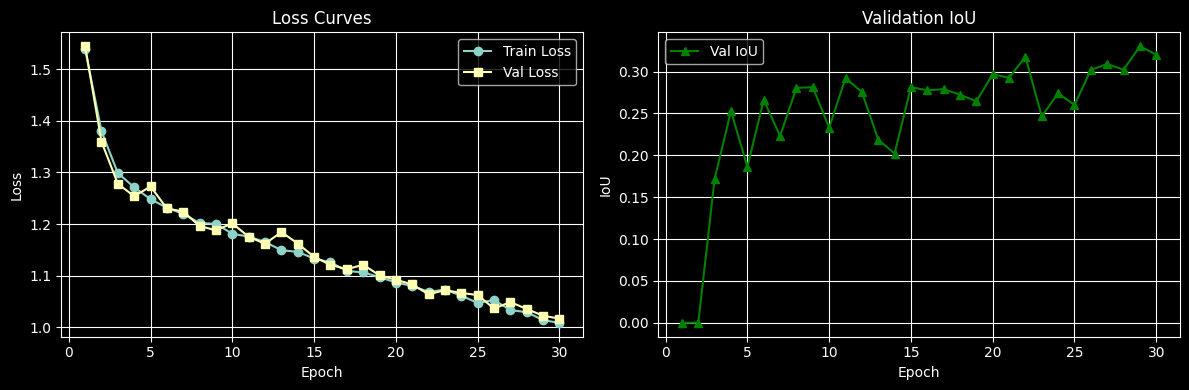

Loss curve saved to: C:\Users\saiki\PycharmProjects\flood_project_Clean\outputs\prajwal\loss_curve.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log_df["epoch"], log_df["train_loss"], label="Train Loss", marker="o")
axes[0].plot(log_df["epoch"], log_df["val_loss"],   label="Val Loss",   marker="s")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(log_df["epoch"], log_df["val_iou"], label="Val IoU", color="green", marker="^")
axes[1].set_title("Validation IoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUT_DIR / "loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved to:", OUT_DIR / "loss_curve.png")

## 8. Summary

In [15]:
best_epoch = log_df.loc[log_df["val_loss"].idxmin()]
print("=" * 50)
print("BASELINE TRAINING SUMMARY")
print("=" * 50)
print(f"Model        : U-Net (6-channel input, binary output)")
print(f"Parameters   : {total_params:,}")
print(f"Epochs run   : {NUM_EPOCHS}")
print(f"Best epoch   : {int(best_epoch['epoch'])}")
print(f"Best val loss: {best_epoch['val_loss']:.4f}")
print(f"Best val IoU : {best_epoch['val_iou']:.4f}")
print(f"Checkpoint   : outputs/prajwal/checkpoints/best_model.pth")
print(f"Loss curve   : outputs/prajwal/loss_curve.png")
print(f"Training log : outputs/prajwal/training_log.csv")

BASELINE TRAINING SUMMARY
Model        : U-Net (6-channel input, binary output)
Parameters   : 31,039,361
Epochs run   : 30
Best epoch   : 30
Best val loss: 1.0166
Best val IoU : 0.3201
Checkpoint   : outputs/prajwal/checkpoints/best_model.pth
Loss curve   : outputs/prajwal/loss_curve.png
Training log : outputs/prajwal/training_log.csv
